In [77]:
!pip install -q git+https://github.com/gmihaila/ml_things.git

In [78]:
from transformers import set_seed, GPT2Config, GPT2Tokenizer, GPT2ForSequenceClassification

set_seed(731)

model_config = GPT2Config.from_pretrained('gpt2', num_labels=2) # Binary Classification
model = GPT2ForSequenceClassification.from_pretrained('gpt2', config=model_config)

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.padding_side = "left" # Very Important
tokenizer.pad_token = tokenizer.eos_token

model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = model.config.eos_token_id

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [79]:
import os
import pandas as pd

# Load the original dataset
df = pd.read_csv(os.path.join('/kaggle/input/sarcasm-detection-dataset/', 'sarcasm-detection-dataset.csv'))

# Split the dataset into train and test sets (80% train, 20% test)
train_size = int(0.8 * len(df))
train_df = df[:train_size]
test_df = df[train_size:]

# Save train and test sets to separate CSV files
train_df[['text', 'label']].to_csv(os.path.join('/kaggle/working/', 'train.csv'), index=False)
test_df[['text', 'label']].to_csv(os.path.join('/kaggle/working/', 'test.csv'), index=False)

In [80]:
from torch.utils.data import Dataset

class SarcasmDetectionDataset(Dataset):
    def __init__(self, train=True):
        super().__init__()
        self.train = train
        self.data = pd.read_csv(os.path.join('/kaggle/working/', 'train.csv' if train else 'test.csv'))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        record = self.data.iloc[index]
        text = record['text']
        if self.train:
            return {'text': text, 'label': record['label']}
        else:
            return {'text': text, 'label': '0'}

train_dataset = SarcasmDetectionDataset(train=True)
test_dataset = SarcasmDetectionDataset(train=False)

In [81]:
for i in range(10):
    print(train_dataset.__getitem__(i)['text'])

In Pictures: 8 asanas brought to you by PM Modi with commentary by Sagarika Ghose
Diesel costlier by 3 as Bihar government withdraws VAT rebate
NASA Releases Satellite Image Of Apology Letters For #MeToo Coming From India
Global real estate to get uniform international measurement standards soon
Kanye West New Girlfriend, Chaney Jones Leaves Kanye West For Kanye West Lookalike
Pakistan passes Citizenship Amendment Bill, will grant citizenship to persecuted terrorists of neighboring nations
Yogendra Yadav Beaten Up At Immigration For Applying ‘Protester Visa’ To Travel To Canada
CAPTION THIS: Arun Jaitley, the fist pumper
DGCA licence received for Pithoragarh airport: Finance minister Prakash Pant
UnReal Toon: Movement from Congress’ Indian-Nest to Modi’s Indian-ness


In [82]:
class Gpt2ClassificationCollator(object):
    def __init__(self, tokenizer, max_seq_len=None):
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len
        
        return
    
    def __call__(self, sequences):
        texts = [sequence['text'] for sequence in sequences]
        labels = [int(sequence['label']) for sequence in sequences]
        inputs = self.tokenizer(text=texts,
                                return_tensors='pt',
                                padding=True,
                                truncation=True,
                                max_length=self.max_seq_len)
        inputs.update({'labels': torch.tensor(labels)})
        
        return inputs

gpt2classificationcollator = Gpt2ClassificationCollator(tokenizer=tokenizer,
                                                        max_seq_len=60)

In [83]:
from torch.utils.data import DataLoader, random_split

train_size = int(len(train_dataset) * 0.8)
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=32,
                              shuffle=True,
                              collate_fn=gpt2classificationcollator)
val_dataloader = DataLoader(dataset=val_dataset,
                            batch_size=32,
                            shuffle=False,
                            collate_fn=gpt2classificationcollator)
test_dataloader = DataLoader(dataset=test_dataset,
                             batch_size=32,
                             shuffle=False,
                             collate_fn=gpt2classificationcollator)

In [84]:
from transformers import AdamW, get_cosine_schedule_with_warmup
import torch

total_epochs = 20

param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'LayerNorm.bias', 'LayerNorm.weight']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)], 'weight_decay': 0.0}
]
optimizer = torch.optim.AdamW(optimizer_grouped_parameters,
                  lr=1e-5,
                  eps=1e-8)

num_train_steps = len(train_dataloader) * total_epochs
num_warmup_steps = int(num_train_steps * 0.1) 

lr_scheduler = get_cosine_schedule_with_warmup(optimizer,
                                               num_warmup_steps=num_warmup_steps,
                                               num_training_steps = num_train_steps)

In [85]:
import torch

def train(dataloader, optimizer, scheduler, device_):
    global model
    model.train()
    
    prediction_labels = []
    true_labels = []
    
    total_loss = []
    
    for batch in dataloader:
        true_labels += batch['labels'].numpy().flatten().tolist()
        batch = {k:v.type(torch.long).to(device_) for k, v in batch.items()}
        
        
        outputs = model(**batch)
        loss, logits = outputs[:2]
        logits = logits.detach().cpu().numpy()
        total_loss.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # prevent exploding gradient

        optimizer.step()
        scheduler.step()
        
        prediction_labels += logits.argmax(axis=-1).flatten().tolist()
    
    return true_labels, prediction_labels, total_loss

def validation(dataloader, device_):
    global model
    model.eval()
    
    prediction_labels = []
    true_labels = []
    
    total_loss = []
    
    for batch in dataloader:
        true_labels += batch['labels'].numpy().flatten().tolist()
        batch = {k:v.type(torch.long).to(device_) for k, v in batch.items()}
        
        with torch.no_grad():
            outputs = model(**batch)
            loss, logits = outputs[:2]
            logits = logits.detach().cpu().numpy()
            total_loss.append(loss.item())

            prediction_labels += logits.argmax(axis=-1).flatten().tolist()
        
    return true_labels, prediction_labels, total_loss

In [86]:
from sklearn.metrics import classification_report, accuracy_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

all_loss = {'train_loss': [], 'val_loss': []}
all_acc = {'train_acc': [], 'val_acc': []}

for epoch in range(total_epochs):
    y, y_pred, train_loss = train(train_dataloader, optimizer, lr_scheduler, device)
    train_acc = accuracy_score(y, y_pred)
    
    y, y_pred, val_loss = validation(val_dataloader, device)
    val_acc = accuracy_score(y, y_pred)
    
    all_loss['train_loss'] += train_loss
    all_loss['val_loss'] += val_loss
    
    all_acc['train_acc'].append(train_acc)
    all_acc['val_acc'].append(val_acc)
    
    print(f'Epoch: {epoch}, train_loss: {torch.tensor(train_loss).mean():.3f}, train_acc: {train_acc:.3f}, val_loss: {torch.tensor(val_loss).mean():.3f}, val_acc: {val_acc:.3f}') 

Epoch: 0, train_loss: 0.895, train_acc: 0.536, val_loss: 0.575, val_acc: 0.696
Epoch: 1, train_loss: 0.521, train_acc: 0.737, val_loss: 0.308, val_acc: 0.863
Epoch: 2, train_loss: 0.315, train_acc: 0.859, val_loss: 0.222, val_acc: 0.908
Epoch: 3, train_loss: 0.244, train_acc: 0.903, val_loss: 0.167, val_acc: 0.933
Epoch: 4, train_loss: 0.200, train_acc: 0.920, val_loss: 0.156, val_acc: 0.945
Epoch: 5, train_loss: 0.163, train_acc: 0.934, val_loss: 0.145, val_acc: 0.947
Epoch: 6, train_loss: 0.144, train_acc: 0.947, val_loss: 0.147, val_acc: 0.951
Epoch: 7, train_loss: 0.125, train_acc: 0.953, val_loss: 0.137, val_acc: 0.958
Epoch: 8, train_loss: 0.120, train_acc: 0.955, val_loss: 0.171, val_acc: 0.937
Epoch: 9, train_loss: 0.097, train_acc: 0.962, val_loss: 0.142, val_acc: 0.954
Epoch: 10, train_loss: 0.088, train_acc: 0.966, val_loss: 0.149, val_acc: 0.959
Epoch: 11, train_loss: 0.078, train_acc: 0.971, val_loss: 0.176, val_acc: 0.947
Epoch: 12, train_loss: 0.076, train_acc: 0.972, va

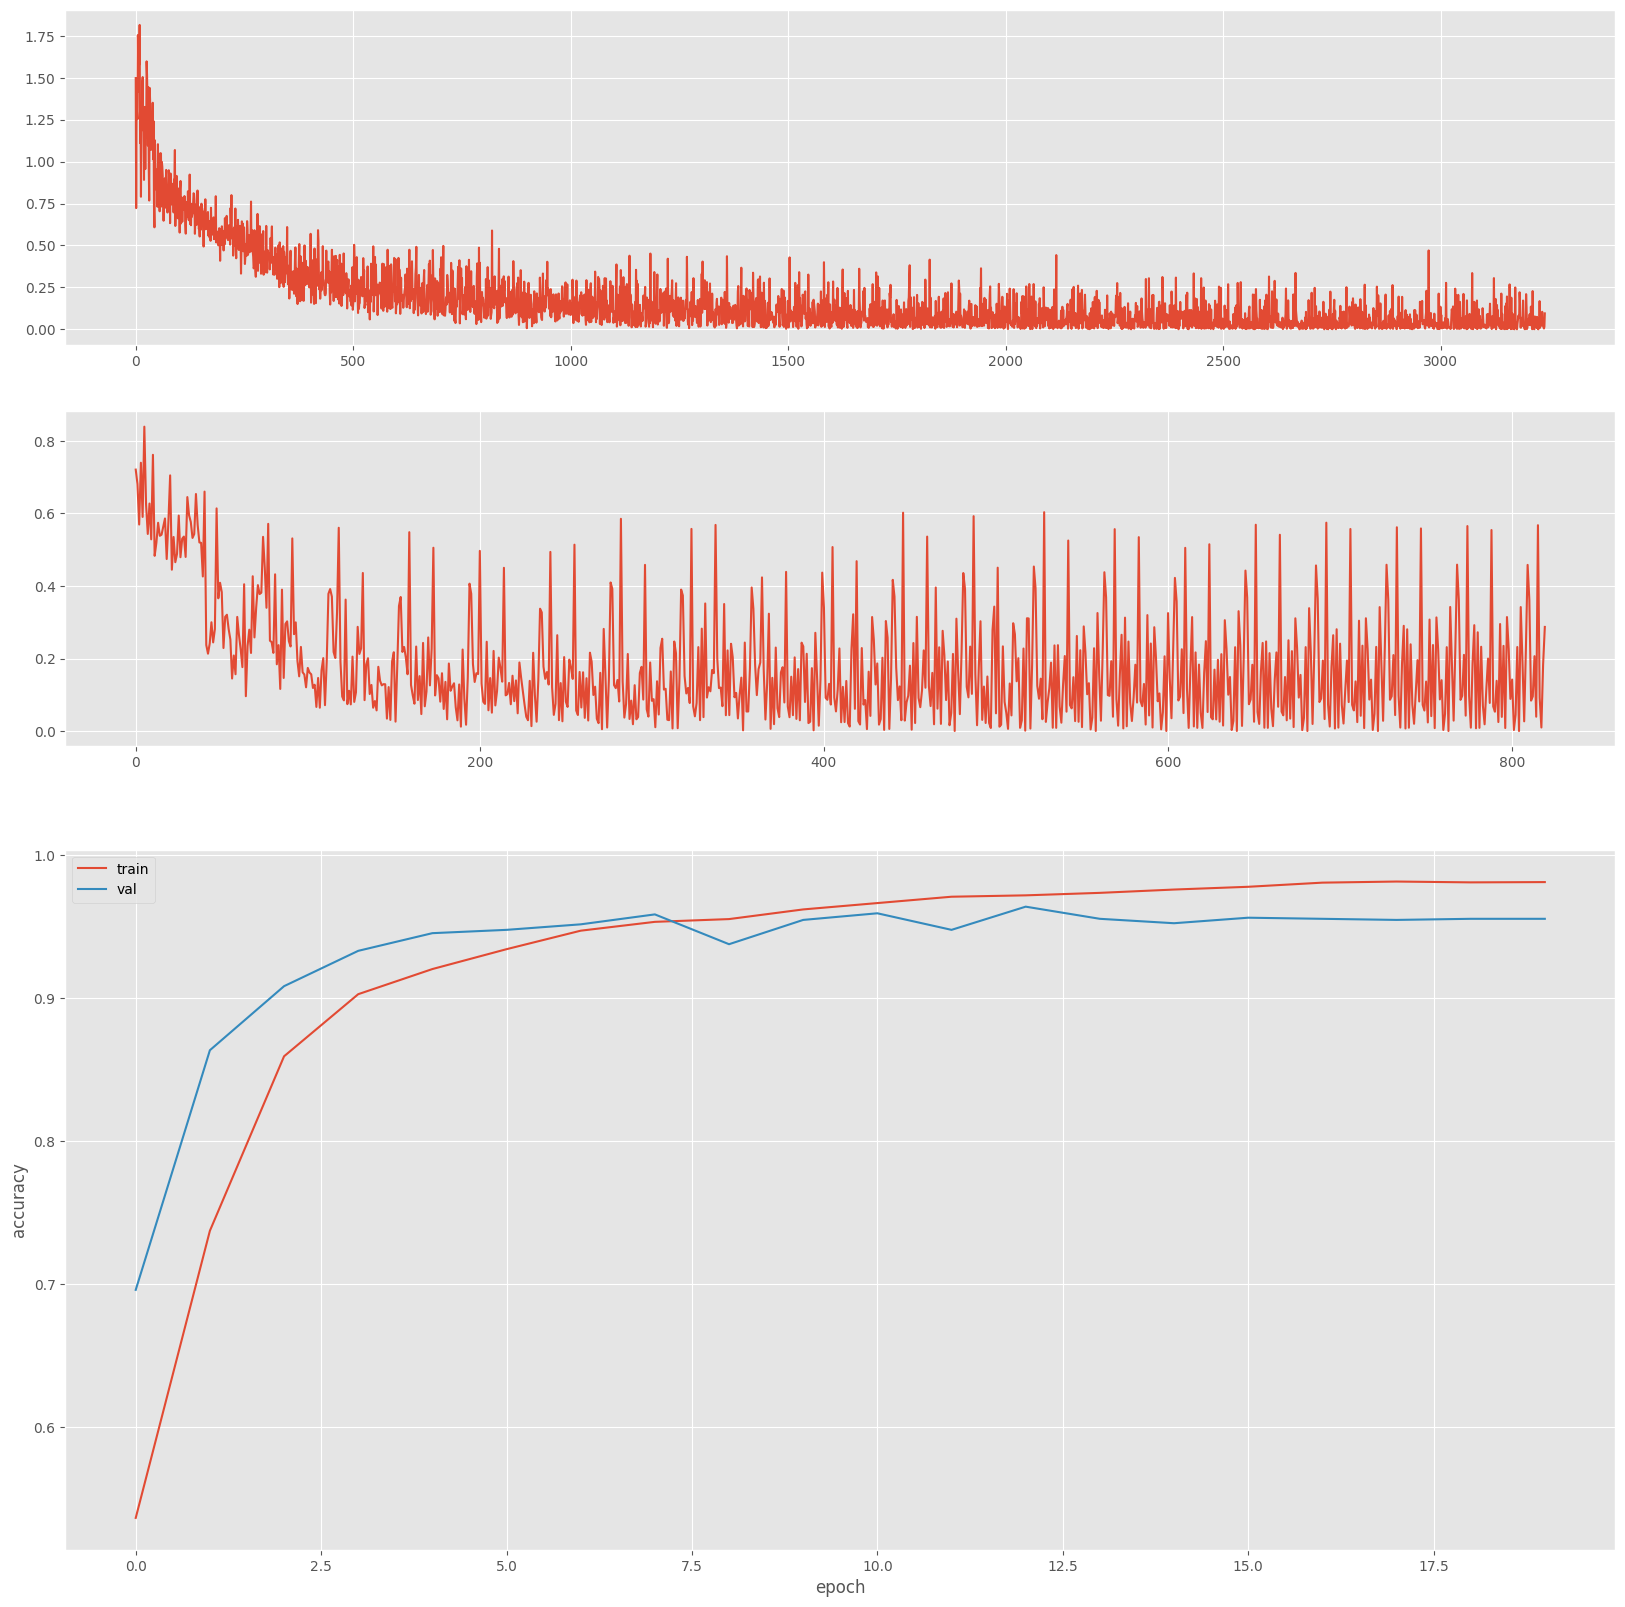

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fig = plt.figure(figsize=(20,20))
a = fig.add_subplot(4, 1, 1)
b = fig.add_subplot(4, 1, 2)
c = fig.add_subplot(2, 1, 2)
a.plot(all_loss['train_loss'])
b.plot(all_loss['val_loss'])
c.plot(all_acc['train_acc'])
c.plot(all_acc['val_acc'])
c.set(xlabel='epoch', ylabel='accuracy')
c.legend(['train', 'val'])

pass

In [88]:
_, predictions_labels, _ = validation(test_dataloader, device)
# avg_epoch_loss = sum(total_loss)/len(total_loss)

In [92]:
print(predictions_labels)

[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 

In [95]:
print(len(predictions_labels))

1619


In [101]:
print(test_dataset.data.iloc[0]['label'])

0


In [104]:
true_label_0_predicted_label_0=0
true_label_0_predicted_label_1=0
true_label_1_predicted_label_0=0
true_label_1_predicted_label_1=0
for i in range(0, len(predictions_labels)):
    if test_dataset.data.iloc[i]['label']==0 and predictions_labels[i]==0:
        true_label_0_predicted_label_0+=1
    elif test_dataset.data.iloc[i]['label']==0 and predictions_labels[i]==1:
        true_label_0_predicted_label_1+=1
    elif test_dataset.data.iloc[i]['label']==1 and predictions_labels[i]==0:
        true_label_1_predicted_label_0+=1
    else:
        true_label_1_predicted_label_1+=1

In [106]:
print(true_label_0_predicted_label_0)
print(true_label_0_predicted_label_1)
print(true_label_1_predicted_label_0)
print(true_label_1_predicted_label_1)

773
45
28
773


In [108]:
true_labels=[]
for i in range(0, len(predictions_labels)):
    true_labels.append(test_dataset.data.iloc[i]['label'])

In [109]:
print(true_labels)

[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 

In [110]:
# evaluation_report = classification_report(true_labels, predictions_labels, labels=[0, 1], target_names=list(labels_ids.keys()))
evaluation_report = classification_report(true_labels, predictions_labels, labels=[0, 1], zero_division='warn')
print(evaluation_report)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       818
           1       0.94      0.97      0.95       801

    accuracy                           0.95      1619
   macro avg       0.96      0.96      0.95      1619
weighted avg       0.96      0.95      0.95      1619



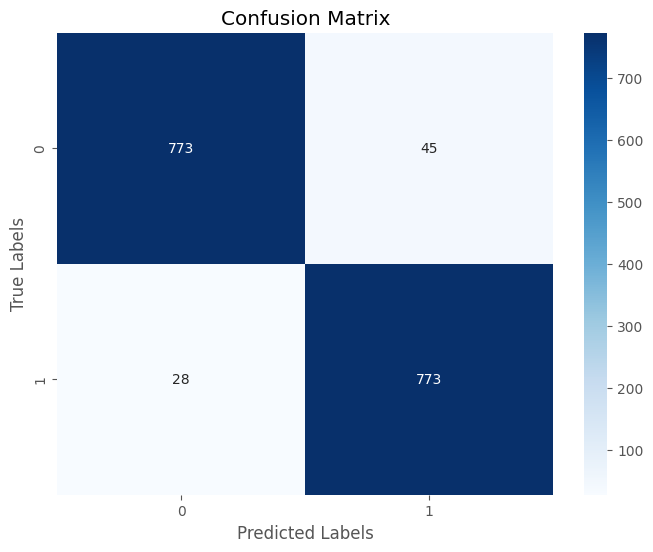

In [111]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(true_labels, predictions_labels)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0', '1'], 
            yticklabels=['0', '1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()